# Score de Prioridade e Simulação de Impacto

O modelo de classificação desenvolvido na etapa anterior prevê a probabilidade de um chamado atrasar. Mas probabilidade de atraso não é o único critério relevante para alocar atenção operacional: um chamado com 60% de chance de atrasar em uma área vulnerável pode ser mais urgente do que um com 70% de chance em um bairro com infraestrutura consolidada.

Este notebook constrói um **score de prioridade** que combina o sinal do modelo com critérios de equidade territorial, urgência por tipo de chamado e contexto climático. Em seguida, simula e compara duas estratégias de alocação dos 20% de chamados que podem receber atenção especial:

1. **Seleção aleatória**: linha de base sem inteligência.
2. **Top 20% pelo score**: priorização orientada por dados.

A estrutura segue três etapas:
1. **Carregamento**: modelo e dados de teste salvos na etapa anterior.
2. **Construção do score**: fórmula ponderada com justificativa de cada componente.
3. **Simulação e impacto**: métricas comparativas, lift curve e recomendação fundamentada.

## 1. Configuração do Ambiente

In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})

## 2. Carregamento dos Dados

O modelo treinado e os dados de teste com probabilidades foram exportados ao final do notebook anterior. O conjunto de teste cobre todo o ano de 2024 — período não visto pelo modelo durante o treinamento.

In [ ]:
# Carregar modelo e dados de teste
pipeline_final = joblib.load("../data/pipeline_final.pkl")

df = pd.read_parquet("../data/df_teste_com_predicoes.parquet")
df["data_inicio"] = pd.to_datetime(df["data_inicio"])

print(f"Registros: {len(df):,}")
print(f"Colunas:   {df.shape[1]}")
print(f"Período:   {df['data_inicio'].min().date()} a {df['data_inicio'].max().date()}")
print(f"\nColunas de predição disponíveis:")
print(df[["y_real", "y_pred", "y_proba"]].describe().round(3))

Registros: 25,870
Colunas:   58
Período:   2024-01-01 a 2024-12-31

Colunas de predição disponíveis:
          y_real     y_pred    y_proba
count  25870.000  25870.000  25870.000
mean       0.793      0.995      0.894
std        0.405      0.067      0.107
min        0.000      0.000      0.298
25%        1.000      1.000      0.834
50%        1.000      1.000      0.941
75%        1.000      1.000      0.975
max        1.000      1.000      0.987


Dois pontos relevantes que os números revelam antes de construir o score:

- **`y_pred` médio de 0,995**: o modelo prevê quase tudo como resolvido no prazo — comportamento esperado dado o `scale_pos_weight` usado no treino para lidar com o desbalanceamento. Para o score, usaremos `y_proba` diretamente, não `y_pred`.
- **`y_proba` entre 0,298 e 0,987, mediana em 0,941**: chamados abaixo do 25º percentil (~0,83) já são candidatos naturais à atenção prioritária.
- **79,3% resolvidos no prazo**: os ~20,7% que atrasaram correspondem quase exatamente à capacidade de atenção disponível (20%), tornando a simulação operacionalmente realista.

## 3. Score de Prioridade

### 3.1 Fórmula e Justificativa

O score proposto é uma média ponderada de cinco componentes, cada um normalizado entre $0$ e $1$:

$$score\_final = 0,45 \times risco + 0,20 \times equidade + 0,20 \times urgência + 0,10 \times clima + 0,05 \times backlog$$

> **Importante:** os pesos abaixo são uma proposta estruturada a partir dos dados, não um resultado otimizado ou validado por especialistas. Em um projeto real, deveriam ser calibrados com gestores da central 1746, que têm conhecimento sobre quais tipos de chamado causam mais dano quando atrasam e quais regiões têm menor capacidade de absorver atrasos.

##### 1. Risco (Peso: 0,45)
É o componente dominante. Utiliza a probabilidade do modelo ($y\_proba$) de forma invertida:
* **Fórmula:** $1 - y\_proba$
* **Lógica:** Se o modelo indica 90% de chance de resolução no prazo, o risco é 0,10.
* **Objetivo:** Quanto menor a confiança do modelo na resolução tempestiva, maior o score de prioridade.

##### 2. Equidade Territorial (Peso: 0,20)
Valor fixo por Área de Planejamento (AP), definido com base nos rankings de tempo de resposta e nos padrões de vulnerabilidade identificados na análise geoespacial (Parte 2):

| Área de Planejamento | Regiões Abrangidas | Valor |
| :--- | :--- | :--- |
| **AP 1 e AP 2** | Centro e Zona Sul | 0,20 |
| **AP 3** | Zona Norte | 0,80 |
| **AP 4** | Barra e Jacarepaguá | 0,60 |
| **AP 5** | Zona Oeste | 1,00 |

> **Nota:** Este critério garante que, em situações de risco igual, chamados de áreas com maior vulnerabilidade tenham precedência sobre áreas com melhor infraestrutura.

##### 3. Urgência por Tipo (Peso: 0,20)
Classificação em três níveis, definida com base nos macro-tipos clima-relevantes da Parte 1 e nos tipos com maior volume de falsos negativos identificados na análise de erros:

* **Alta (1,00):** Defesa Civil, Geotecnia, Inundação, Drenagem, Encostas, Estrutura de Imóvel.
* **Média (0,60):** Pavimentação, Tapa-buraco, Manejo Arbóreo, Limpeza, Remoção Gratuita.
* **Base (0,30):** Todos os demais tipos não classificados.

**Lógica:** Prioriza serviços cujas consequências de atraso são potencialmente mais graves para a integridade física e urbana.

##### 4. Contexto Climático (Peso: 0,10)
Baseia-se na chuva prevista para os próximos 7 dias ($chuva\_prevista\_7d$), normalizada pelos valores mínimo e máximo da base de dados.
* **Impacto:** Semanas com previsão de alta pluviosidade elevam o score de todos os chamados abertos, refletindo a dificuldade operacional de execução de serviços de campo sob chuva — padrão identificado na análise exploratória da Parte 1.

##### 5. Backlog Operacional (Peso: 0,05)
Refere-se ao número de chamados já abertos na unidade responsável, devidamente normalizado.
* **Justificativa de Peso:** Recebe o menor peso pois este fator já é parcialmente capturado pelo risco do modelo — foi uma das variáveis mais relevantes no treinamento do XGBoost, e duplicá-lo com peso alto contaria o mesmo sinal duas vezes.

---

Os pesos foram escolhidos para manter o sinal preditivo do modelo como âncora principal, sem que os critérios normativos (equidade e urgência) o sobrescrevam totalmente.
* Um chamado de **baixo risco** não atingirá o topo da lista apenas por critérios geográficos.
* O sistema atua como um **desempate técnico**: entre dois chamados com riscos similares, a equidade e a urgência definem a prioridade final.

### 3.2 Cálculo do Score

In [ ]:
# Imputação de missings antes da normalização
df["chuva_prevista_7d"] = df["chuva_prevista_7d"].fillna(df["chuva_prevista_7d"].median())

# Componente 1: Risco (invertido da probabilidade do modelo)
df["score_risco"] = 1 - df["y_proba"]

# Componente 2: Equidade territorial
mapa_equidade = {1: 0.2, 2: 0.2, 3: 0.8, 4: 0.6, 5: 1.0}
df["score_equidade"] = df["id_area_planejamento_numerico"].map(mapa_equidade).fillna(0.5)

# Componente 3: Urgência por tipo de chamado
tipos_alta_urgencia  = [
    "Defesa civil", "Geotecnia", "Inundação, alagamento",
    "Drenagem e Saneamento", "Encostas", "Estrutura de Imóvel",
]
tipos_media_urgencia = [
    "Pavimentação", "Tapa-buraco", "Manejo Arbóreo",
    "Limpeza de logradouros", "Remoção Gratuita",
]
df["score_urgencia"] = 0.3
df.loc[df["tipo"].isin(tipos_media_urgencia), "score_urgencia"] = 0.6
df.loc[df["tipo"].isin(tipos_alta_urgencia),  "score_urgencia"] = 1.0

# Componente 4: Contexto climático (normalizado 0-1)
chuva_min = df["chuva_prevista_7d"].min()
chuva_max = df["chuva_prevista_7d"].max()
df["score_clima"] = (df["chuva_prevista_7d"] - chuva_min) / (chuva_max - chuva_min)

# Componente 5: Backlog operacional (normalizado 0-1)
bl_min = df["qtd_chamados_abertos_unidade"].min()
bl_max = df["qtd_chamados_abertos_unidade"].max()
df["score_backlog"] = (df["qtd_chamados_abertos_unidade"] - bl_min) / (bl_max - bl_min)

# Score final ponderado
df["score_final"] = (
    0.45 * df["score_risco"]    +
    0.20 * df["score_equidade"] +
    0.20 * df["score_urgencia"] +
    0.10 * df["score_clima"]    +
    0.05 * df["score_backlog"]
)

print("Distribuição do score final:")
print(df["score_final"].describe().round(3))
print(f"\nLimiar top 20%: {df['score_final'].quantile(0.80):.3f}")

count    25870.000
mean         0.251
std          0.081
min          0.166
25%          0.184
50%          0.221
75%          0.297
max          0.576
Name: score_final, dtype: float64

Limiar top 20%: 0.312


## 4. Simulação de Estratégias de Priorização

### 4.1 Definição das Estratégias

O órgão tem capacidade para dar atenção especial a **20% dos chamados**. Comparamos duas formas de selecionar esse subconjunto:

- **Aleatória**: seleção sem critério, usada como linha de base.
- **Score**: top 20% pelo score de prioridade construído acima.

O "positivo" nesta simulação é o chamado que **atrasou** (`y_real == 0`) — o evento que queremos antecipar. Recall mede quantos desses atrasos foram capturados; precisão mede o quanto dos priorizados de fato atrasariam.

In [ ]:
N_PRIORIZAR = int(len(df) * 0.20)

# Estratégia 1: Aleatória
np.random.seed(100)
idx_aleatorio = np.random.choice(df.index, size=N_PRIORIZAR, replace=False)
df["priorizados_aleatorio"] = 0
df.loc[idx_aleatorio, "priorizados_aleatorio"] = 1

# Estratégia 2: Top 20% pelo score
limiar = df["score_final"].quantile(0.80)
df["priorizados_score"] = (df["score_final"] >= limiar).astype(int)

# Métricas comparativas
resultados = {}
for nome, col in [("Aleatório", "priorizados_aleatorio"), ("Score", "priorizados_score")]:
    priorizados              = df[df[col] == 1]
    atrasados_capturados     = (1 - priorizados["y_real"]).sum()
    total_atrasados          = (1 - df["y_real"]).sum()

    resultados[nome] = {
        "Chamados priorizados":                   len(priorizados),
        "Atrasados capturados":                   int(atrasados_capturados),
        "Total atrasados (base)": int(total_atrasados),
        "Recall (% atrasados capturados)":        atrasados_capturados / total_atrasados,
        "Precisão (% priorizados que atrasariam)": (1 - priorizados["y_real"]).mean(),
    }

df_comparativo = pd.DataFrame(resultados).T
print("─" * 65)
print("Comparativo de Estratégias (20% dos chamados priorizados)")
print("─" * 65)
display(df_comparativo.round(3))

────────────────────────────────────────────────────────────
Comparativo de Estratégias (20% dos chamados priorizados)
────────────────────────────────────────────────────────────


,Chamados priorizados,Atrasados capturados,Total atrasados (base),Recall (% atrasados capturados),Precisão (% priorizados que atrasariam)
Aleatório,5174.0,1008.0,5357.0,0.188,0.195
Score,5174.0,2697.0,5357.0,0.503,0.521


### 4.2 Lift Curve e Recall Acumulado

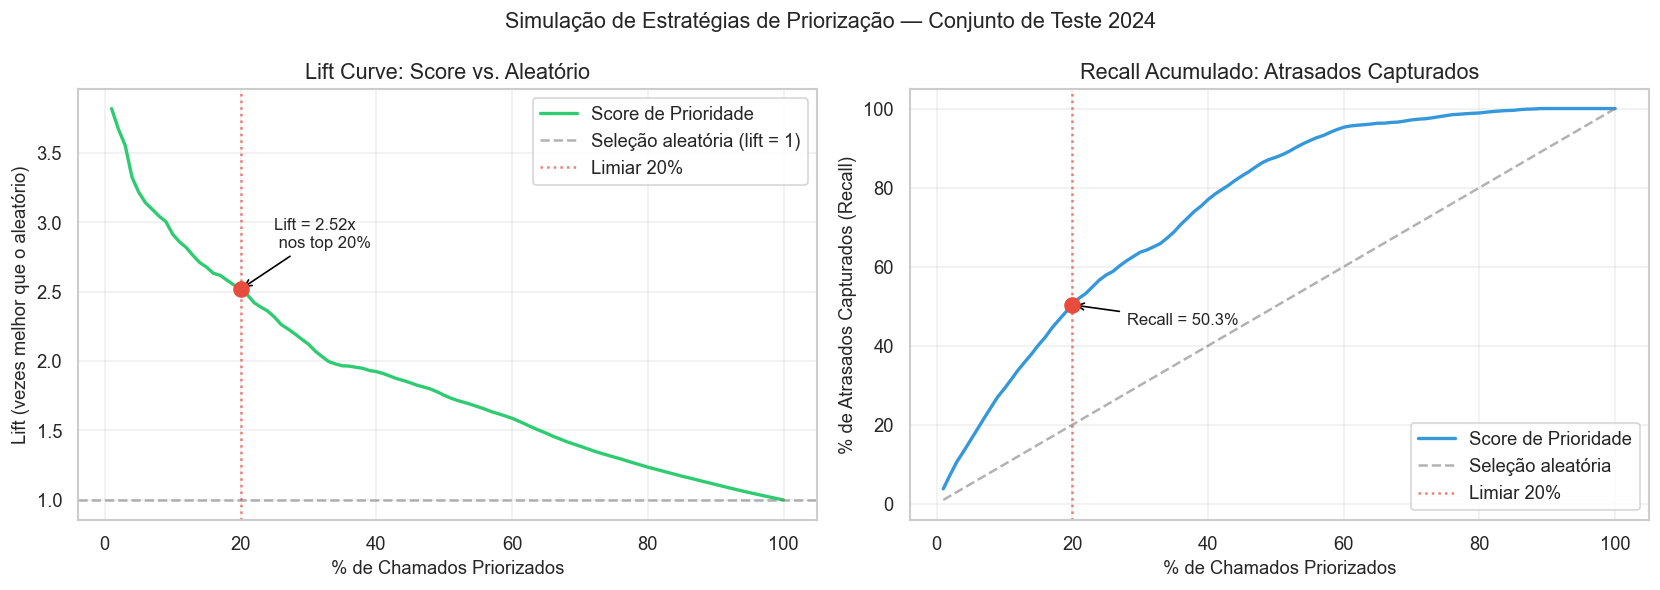

In [7]:
# ── Lift Curve ───────────────────────────────────────────────────────────────
# Ordena pelo score e calcula o lift acumulado
df_lift = df.sort_values("score_final", ascending=False).copy()
df_lift["atrasou"] = 1 - df_lift["y_real"]

taxa_base   = df_lift["atrasou"].mean()
percentuais = np.arange(0.01, 1.01, 0.01)
lift_vals   = []
recall_vals = []

for p in percentuais:
    n = int(len(df_lift) * p)
    capturados = df_lift.iloc[:n]["atrasou"].mean()
    lift_vals.append(capturados / taxa_base)
    recall_vals.append(df_lift.iloc[:n]["atrasou"].sum() / df_lift["atrasou"].sum())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Lift Curve
ax1.plot(percentuais * 100, lift_vals, color="#2ecc71", linewidth=2, label="Score de Prioridade")
ax1.axhline(1.0, color="gray", linestyle="--", alpha=0.6, label="Seleção aleatória (lift = 1)")
ax1.axvline(20,  color="#e74c3c", linestyle=":", alpha=0.7, label="Limiar 20%")
ax1.scatter([20], [lift_vals[19]], color="#e74c3c", zorder=5, s=80)
ax1.annotate(f"Lift = {lift_vals[19]:.2f}x\n nos top 20%",
             xy=(20, lift_vals[19]), xytext=(25, lift_vals[19] + 0.3),
             arrowprops=dict(arrowstyle="->", color="black"), fontsize=10)
ax1.set_title("Lift Curve: Score vs. Aleatório")
ax1.set_xlabel("% de Chamados Priorizados")
ax1.set_ylabel("Lift (vezes melhor que o aleatório)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Recall Curve
ax2.plot(percentuais * 100, [r * 100 for r in recall_vals],
         color="#3498db", linewidth=2, label="Score de Prioridade")
ax2.plot(percentuais * 100, percentuais * 100,
         color="gray", linestyle="--", alpha=0.6, label="Seleção aleatória")
ax2.axvline(20, color="#e74c3c", linestyle=":", alpha=0.7, label="Limiar 20%")
ax2.scatter([20], [recall_vals[19] * 100], color="#e74c3c", zorder=5, s=80)
ax2.annotate(f"Recall = {recall_vals[19]*100:.1f}%",
             xy=(20, recall_vals[19] * 100), xytext=(28, recall_vals[19] * 100 - 5),
             arrowprops=dict(arrowstyle="->", color="black"), fontsize=10)
ax2.set_title("Recall Acumulado: Atrasados Capturados")
ax2.set_xlabel("% de Chamados Priorizados")
ax2.set_ylabel("% de Atrasados Capturados (Recall)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Simulação de Estratégias de Priorização — Conjunto de Teste 2024", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Análise e Recomendação

Com o mesmo orçamento de atenção — 5.174 chamados, correspondente a 20% da base de teste — as duas estratégias produzem resultados extremamente diferentes. A seleção aleatória captura 1.008 dos 5.357 chamados que realmente atrasaram, um recall de 18,8% e precisão de 19,5%, números que refletem basicamente a proporção natural de atrasos na base. O score de prioridade captura 2.697 atrasados com recall de 50,3% e precisão de 52,1% — ou seja, mais da metade dos chamados priorizados pelo score de fato atrasariam, e mais da metade de todos os atrasos da cidade seriam detectados com antecedência usando apenas 20% da capacidade operacional.

**Lift Curve**

O lift de 2,52x no limiar dos 20% significa que **o score é duas vezes e meia mais eficiente do que a alocação aleatória para identificar chamados em risco**. A curva tem decaimento rápido no início — os primeiros 10% já entregam lift acima de 3x — o que indica que o score consegue concentrar os casos mais críticos no topo do ranking com boa separação. Isso é relevante do ponto de vista operacional: se a capacidade disponível for ainda menor do que 20%, o ganho proporcional é ainda maior.

**Equilíbrio entre Eficiência e Equidade**
A fórmula proposta equilibra os dois objetivos explicitamente nos pesos: 45% para o risco do modelo (eficiência), 20% para equidade territorial e 20% para urgência do tipo de chamado. Na prática, isso significa que um chamado de Defesa Civil aberto na AP 5 (Zona Oeste) com chuva prevista recebe score mais alto do que um chamado de Estacionamento Irregular no Centro com a mesma probabilidade de atraso — mesmo que o modelo os trate de forma similar. O bônus de equidade não substitui o sinal do modelo, mas impede que regiões periféricas sejam sistematicamente preteridas quando os scores de risco são próximos.

**Recomendação**
A estratégia baseada em score deve ser adotada. O ganho quantificado é direto: para cada 100 chamados priorizados pelo score, 52 realmente atrasariam — contra 20 na seleção aleatória. Em termos absolutos, isso representa 1.689 atrasos adicionais identificados com antecedência no conjunto de teste, com a mesma capacidade operacional. A recomendação de implementação é usar o score como fila de triagem diária, atualizando as probabilidades do modelo a cada abertura de chamado e revisando os pesos de equidade semestralmente com base nos dados de tempo de resposta por subprefeitura — garantindo que o critério de equidade acompanhe eventuais mudanças na capacidade instalada de cada região.